# Comparación experimental del minigestor

Se usan los CSV reproducibles de data/generated: 1 000, 10 000 y 100 000 registros. Cada corrida crea archivos nuevos y mide con perf_counter. Los datos se cargan antes del cronómetro. Solo se agregan al resumen las mediciones completas y validadas. Las corridas que superan el límite de tiempo quedan registradas como tales, sin extrapolación.

Las mediciones de índices incluyen construcción del índice desde registros preexistentes. El B+ agrupado usa un archivo secuencial ordenado; su carga física se registra por separado. En los tres índices, igualdad compara búsquedas de clave a RID. El hash no ofrece rango ni recorrido ordenado. El espacio adicional de los índices excluye el archivo de datos.

In [1]:
import csv
import statistics
import sys
import tempfile
from collections import Counter, defaultdict
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "benchmarks":
    ROOT = ROOT.parent
DATA = ROOT / "data" / "generated"
OUTPUT = ROOT / "data" / "benchmarks"
sys.path.insert(0, str(ROOT / "backend"))

from engine.storage.heap.heapfile import Heapfile
from engine.storage.sequential.sequential_file import SequentialFile
from engine.bplus import BPlusTree, ClusteredBPlusTree
from engine.hashing import ExtendibleHashIndex, external_group_by, grace_hash_join
from engine.external import external_sort

SIZES = (1_000, 10_000, 100_000)
REPEATS = 3
PAGE_SIZE = 4096
BLOCK_FACTOR = 32
STORAGE_LIMIT_SECONDS = 15
INDEX_LIMIT_SECONDS = 90
raw_results = []


## Carga y validación de entrada

Los identificadores son únicos, los detalles apuntan a registros existentes y cada tamaño usa el mismo orden de inserción en todas las repeticiones. Los archivos de entrada quedan fuera del tiempo medido.

In [2]:
def load_data(size):
    with (DATA / f"records_{size}.csv").open(newline="") as file:
        reader = csv.reader(file)
        next(reader)
        records = [tuple(map(int, row)) for row in reader]
    with (DATA / f"details_{size}.csv").open(newline="") as file:
        reader = csv.reader(file)
        next(reader)
        details = [tuple(map(int, row)) for row in reader]
    ids = {row[0] for row in records}
    assert len(records) == len(ids) == size and ids == set(range(size))
    assert len(details) == 2 * size
    assert all(row[1] in ids for row in details)
    return records, details

def query_keys(size):
    return list(range(0, size, max(1, size // 20)))[:20]

def disk_size(path):
    path = Path(path)
    if path.is_file():
        return path.stat().st_size
    return sum(file.stat().st_size for file in path.iterdir() if file.is_file())

def record(suite, technique, operation, size, repeat, status, seconds=None, disk_bytes=None, processed=None):
    raw_results.append((suite, technique, operation, size, repeat, status, seconds, disk_bytes, processed))
    print(f"{suite} | {technique} | {operation} | {size} | {repeat} | {status} | {seconds}")


## 2.1.1 Gestión de archivos

La inserción parte de un archivo vacío. La búsqueda mide las mismas 20 claves en ambos archivos. La reorganización del secuencial se mide después de marcar 20 % de sus registros; durante ese tramo se desactiva la reorganización automática para aislar el costo de la operación explícita.

In [3]:
def benchmark_storage(kind, rows, size, repeat):
    with tempfile.TemporaryDirectory() as tmp:
        path = Path(tmp) / ("table.dat" if kind == "heap" else "table.seq")
        current = "insert"
        start = perf_counter()
        processed = 0
        try:
            if kind == "heap":
                storage = Heapfile(str(path), PAGE_SIZE, "iii")
                for processed, row in enumerate(rows, 1):
                    storage.insert(*row)
                    if processed < size and processed % 25 == 0 and perf_counter() - start > STORAGE_LIMIT_SECONDS:
                        record("storage", kind, current, size, repeat, "time_limit",
                               perf_counter() - start, disk_size(path), processed)
                        return False
                seconds = perf_counter() - start
                valid = storage.read_file_header()[2] == size
                record("storage", kind, current, size, repeat, "ok" if valid else "validation_failed",
                       seconds, disk_size(path), processed)
                if not valid:
                    return False
                start = perf_counter()
                found = [storage.search(0, key) for key in query_keys(size)]
                seconds = perf_counter() - start
                valid = all(len(matches) == 1 and matches[0][1][0] == key
                            for key, matches in zip(query_keys(size), found))
                record("storage", kind, "equality_20", size, repeat,
                       "ok" if valid else "validation_failed", seconds, disk_size(path), 20)
                return valid

            storage = SequentialFile(str(path), "iii", page_size=PAGE_SIZE)
            for processed, row in enumerate(rows, 1):
                storage.insert(row)
                if processed < size and processed % 100 == 0 and perf_counter() - start > INDEX_LIMIT_SECONDS:
                    record("storage", kind, current, size, repeat, "time_limit",
                           perf_counter() - start, disk_size(path), processed)
                    return False
            seconds = perf_counter() - start
            valid = [row[0] for row in storage.scan()] == list(range(size))
            record("storage", kind, current, size, repeat, "ok" if valid else "validation_failed",
                   seconds, disk_size(path), processed)
            if not valid:
                return False
            start = perf_counter()
            found = [storage.search(key) for key in query_keys(size)]
            seconds = perf_counter() - start
            valid = all(row is not None and row[0] == key
                        for key, row in zip(query_keys(size), found))
            record("storage", kind, "equality_20", size, repeat,
                   "ok" if valid else "validation_failed", seconds, disk_size(path), 20)
            if not valid:
                return False

            storage.waste_threshold = 1.0
            removed = size // 5
            for key in range(removed):
                storage.delete(key)
            current = "reorganize"
            start = perf_counter()
            storage.reorganize()
            seconds = perf_counter() - start
            valid = [row[0] for row in storage.scan()] == list(range(removed, size))
            record("storage", kind, current, size, repeat,
                   "ok" if valid else "validation_failed", seconds, disk_size(path), size - removed)
            return valid
        except Exception:
            record("storage", kind, current, size, repeat, "validation_failed",
                   perf_counter() - start, disk_size(path), processed)
            return False


## 2.1.2 Índices

La construcción del B+ agrupado parte del archivo secuencial ya ordenado; su costo de carga física se muestra aparte. Los otros índices reciben las mismas claves y referencias sintéticas. Se miden 100 consultas exactas repetidas cinco veces, diez rangos de 1 % para los B+, un recorrido ordenado y una carga mixta de 10 % de inserciones y 10 % de eliminaciones. Los resultados se validan antes de registrarlos como completos.

In [4]:
def benchmark_index(kind, rows, size, repeat):
    with tempfile.TemporaryDirectory() as tmp:
        base = Path(tmp)
        index_path = str(base / "index")
        current = "build"
        start = perf_counter()
        processed = 0
        index = None
        try:
            if kind == "bplus_clustered":
                seq = SequentialFile(str(base / "data.seq"), "iii", page_size=PAGE_SIZE)
                load_start = perf_counter()
                seq.bulk_load(rows)
                record("indexes", kind, "physical_load", size, repeat, "ok",
                       perf_counter() - load_start, disk_size(seq.filename), size)
                start = perf_counter()
                index = ClusteredBPlusTree(index_path, seq, "int", block_factor=BLOCK_FACTOR)
                tree = index.tree
                processed = size
            else:
                index = (BPlusTree(index_path, key_type="int", block_factor=BLOCK_FACTOR)
                         if kind == "bplus_unclustered" else
                         ExtendibleHashIndex(index_path, key_type="int", block_factor=BLOCK_FACTOR))
                tree = index
                for processed, row in enumerate(rows, 1):
                    tree.insert(row[0], (row[0], 0))
                    if processed < size and processed % 1000 == 0 and perf_counter() - start > INDEX_LIMIT_SECONDS:
                        record("indexes", kind, current, size, repeat, "time_limit",
                               perf_counter() - start, disk_size(base), processed)
                        return False
            seconds = perf_counter() - start
            index_bytes = sum(file.stat().st_size for file in base.glob("index.*"))
            valid = tree.stats()["entries"] == size
            record("indexes", kind, current, size, repeat, "ok" if valid else "validation_failed",
                   seconds, index_bytes, processed)
            if not valid:
                return False

            keys = list(range(0, size, max(1, size // 100)))[:100]
            start = perf_counter()
            found = [tree.search(key) for _ in range(5) for key in keys]
            seconds = perf_counter() - start
            valid = all(value == [(key, 0)] for key, value in
                        zip(keys * 5, found))
            record("indexes", kind, "equality_500", size, repeat,
                   "ok" if valid else "validation_failed", seconds, index_bytes, 500)
            if not valid:
                return False

            if kind != "hash":
                width = max(1, size // 100)
                starts = list(range(0, size, max(1, size // 10)))[:10]
                start = perf_counter()
                ranges = [tree.range_search(low, min(size - 1, low + width - 1))
                          for low in starts]
                seconds = perf_counter() - start
                valid = all([key for key, _ in found_range] ==
                            list(range(low, min(size, low + width)))
                            for low, found_range in zip(starts, ranges))
                record("indexes", kind, "range_10", size, repeat,
                       "ok" if valid else "validation_failed", seconds, index_bytes, 10)
                start = perf_counter()
                ordered = [key for key, _ in tree.scan()]
                seconds = perf_counter() - start
                valid = ordered == list(range(size))
                record("indexes", kind, "ordered_scan", size, repeat,
                       "ok" if valid else "validation_failed", seconds, index_bytes, size)
                if not valid:
                    return False

            mixed = size // 10
            current = "insert_10pct"
            start = perf_counter()
            for key in range(size, size + mixed):
                if kind == "bplus_clustered":
                    index.insert(key, (key, key % 100, key + 1))
                else:
                    tree.insert(key, (key, 0))
            seconds = perf_counter() - start
            valid = all(tree.search(key) == [(key, 0)]
                        for key in range(size, size + mixed, max(1, mixed // 20)))
            record("indexes", kind, current, size, repeat,
                   "ok" if valid else "validation_failed", seconds, index_bytes, mixed)
            if not valid:
                return False

            current = "delete_10pct"
            start = perf_counter()
            for key in range(mixed):
                if kind == "bplus_clustered":
                    index.delete(key)
                else:
                    tree.delete(key)
            seconds = perf_counter() - start
            valid = tree.stats()["entries"] == size
            valid = valid and all(not tree.search(key)
                                  for key in range(0, mixed, max(1, mixed // 20)))
            valid = valid and all(tree.search(key) == [(key, 0)]
                                  for key in range(size, size + mixed, max(1, mixed // 20)))
            record("indexes", kind, current, size, repeat,
                   "ok" if valid else "validation_failed", seconds,
                   sum(file.stat().st_size for file in base.glob("index.*")), mixed)
            return valid
        except Exception:
            record("indexes", kind, current, size, repeat, "validation_failed",
                   perf_counter() - start, None, processed)
            return False
        finally:
            if index is not None:
                index.close()


## Algoritmos externos

ORDER BY usa mezcla externa sobre la columna value. GROUP BY calcula conteo y suma por category. JOIN une id con record_id. Se consume cada resultado dentro del tiempo medido y se contrasta con un resultado esperado independiente.

In [5]:
def benchmark_external(rows, details, size, repeat):
    expected_groups = defaultdict(lambda: [0, 0])
    for row in rows:
        expected_groups[row[1]][0] += 1
        expected_groups[row[1]][1] += row[2]
    jobs = ("order_by", "group_by", "join")
    for operation in jobs:
        with tempfile.TemporaryDirectory() as tmp:
            start = perf_counter()
            try:
                if operation == "order_by":
                    result = list(external_sort(rows, lambda row: (row[2], row[0]),
                                                mem_budget=1000, tmp_dir=tmp))
                    seconds = perf_counter() - start
                    valid = result == sorted(rows, key=lambda row: (row[2], row[0]))
                    processed = len(result)
                elif operation == "group_by":
                    result = dict(external_group_by(
                        rows, lambda row: row[1],
                        [("count", None), ("sum", lambda row: row[2])],
                        mem_budget=20, tmp_dir=tmp))
                    seconds = perf_counter() - start
                    valid = result == dict(expected_groups)
                    processed = len(result)
                else:
                    count = 0
                    checksum = 0
                    valid = True
                    for parent, child in grace_hash_join(
                        rows, details, lambda row: row[0], lambda row: row[1],
                        mem_budget=1000, tmp_dir=tmp
                    ):
                        count += 1
                        checksum += child[0]
                        valid = valid and parent[0] == child[1]
                    seconds = perf_counter() - start
                    valid = valid and count == 2 * size
                    valid = valid and checksum == (2 * size - 1) * size
                    processed = count
                record("external", "external_algorithm", operation, size, repeat,
                       "ok" if valid else "validation_failed", seconds, None, processed)
            except Exception:
                record("external", "external_algorithm", operation, size, repeat,
                       "validation_failed", perf_counter() - start)


## Ejecución

Tres repeticiones por tamaño para cada caso completo. Si una inserción alcanza el límite de tiempo, se registra su progreso y no se repite esa combinación de estructura y tamaño. Las demás técnicas continúan.

In [6]:
raw_results.clear()
for size in SIZES:
    rows, details = load_data(size)
    active = {"heap": True, "sequential": True}
    for repeat in range(1, REPEATS + 1):
        for kind in ("heap", "sequential"):
            if active[kind]:
                active[kind] = benchmark_storage(kind, rows, size, repeat)
        for kind in ("bplus_clustered", "bplus_unclustered", "hash"):
            benchmark_index(kind, rows, size, repeat)
        benchmark_external(rows, details, size, repeat)
print("Total de registros de medición:", len(raw_results))


storage | heap | insert | 1000 | 1 | ok | 5.229808885999773
storage | heap | equality_20 | 1000 | 1 | ok | 0.30285490400001436
storage | sequential | insert | 1000 | 1 | ok | 0.23058451299993976
storage | sequential | equality_20 | 1000 | 1 | ok | 0.0038295459999062587
storage | sequential | reorganize | 1000 | 1 | ok | 0.014060551000056876
indexes | bplus_clustered | physical_load | 1000 | 1 | ok | 0.0012081410000064352
indexes | bplus_clustered | build | 1000 | 1 | ok | 0.1338905170000544
indexes | bplus_clustered | equality_500 | 1000 | 1 | ok | 0.033685729000353604
indexes | bplus_clustered | range_10 | 1000 | 1 | ok | 0.0007778480003253208
indexes | bplus_clustered | ordered_scan | 1000 | 1 | ok | 0.0014092050000726886
indexes | bplus_clustered | insert_10pct | 1000 | 1 | ok | 0.09636248799961322
indexes | bplus_clustered | delete_10pct | 1000 | 1 | ok | 0.027267304999895714
indexes | bplus_unclustered | build | 1000 | 1 | ok | 0.07494648300007611
indexes | bplus_unclustered | equ

## Resultados y gráficas

El CSV crudo conserva estado, tiempo, bytes y cantidad procesada de cada corrida. El resumen y las curvas usan solo corridas completas y validadas. Los bytes de índices corresponden únicamente a archivos de índice; los bytes de almacenamiento corresponden al archivo de datos.

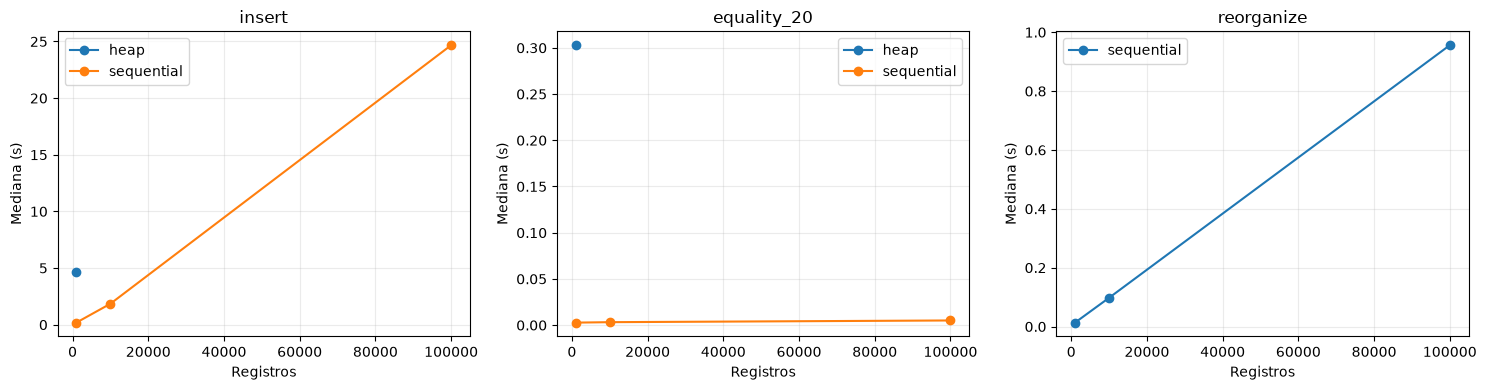

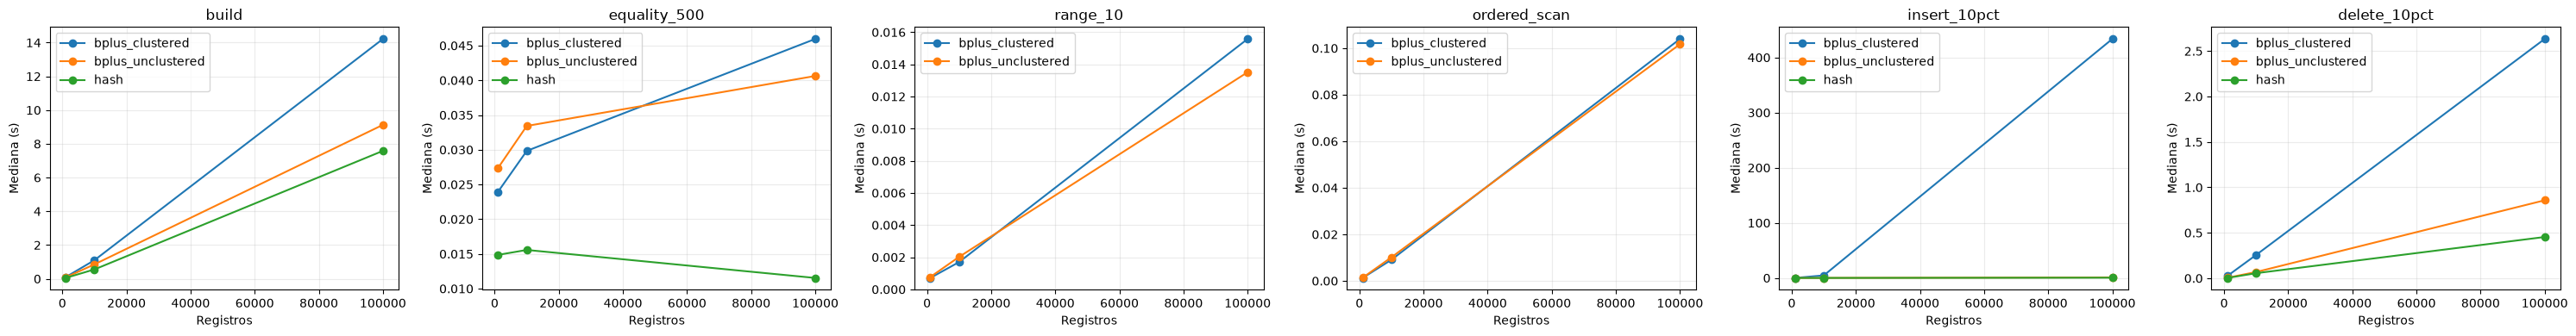

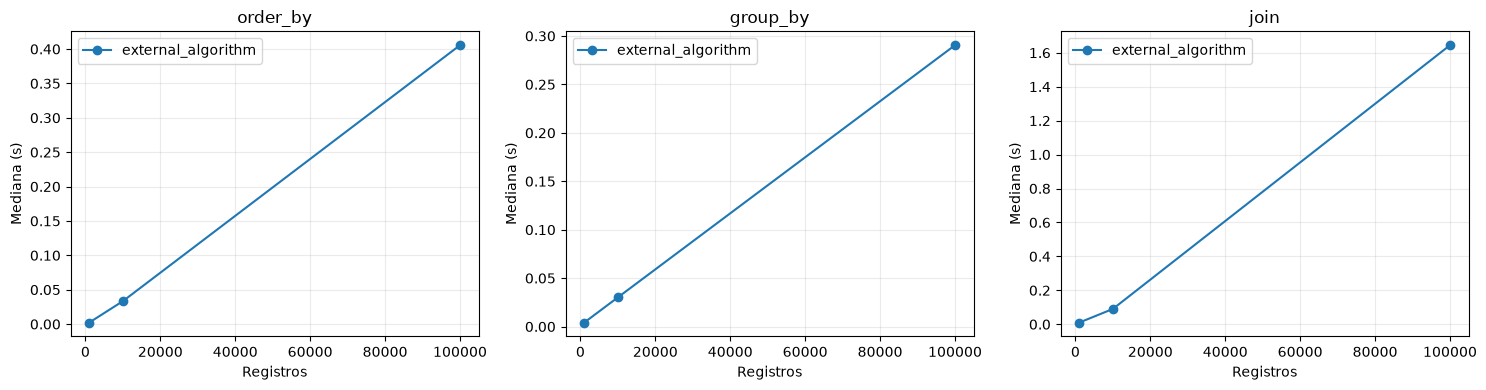

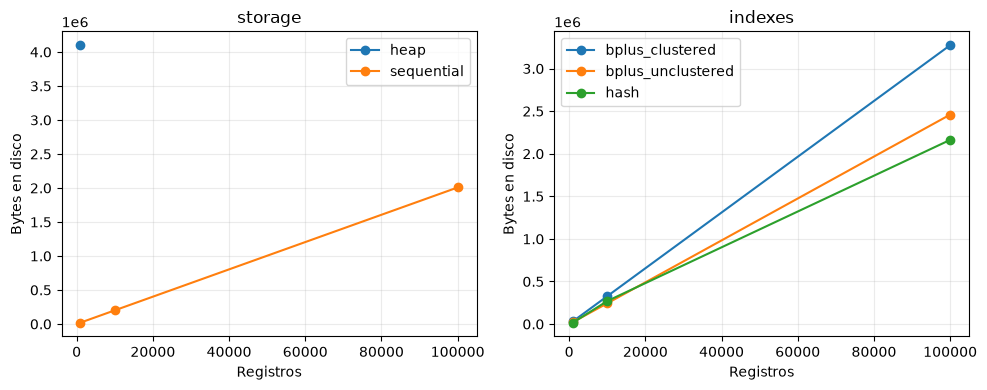

CSV y figuras guardados en /mnt/data/universidad/bd2/proyecto/data/benchmarks
Mediciones completas: 71
Estados: Counter({'ok': 213, 'time_limit': 2})


In [7]:
OUTPUT.mkdir(parents=True, exist_ok=True)
raw_header = ("suite", "technique", "operation", "records", "repeat",
              "status", "seconds", "disk_bytes", "processed")
with (OUTPUT / "results_raw.csv").open("w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(raw_header)
    writer.writerows(raw_results)

groups = defaultdict(list)
for suite, technique, operation, size, repeat, status, seconds, disk_bytes, processed in raw_results:
    if status == "ok":
        groups[(suite, technique, operation, size)].append((seconds, disk_bytes))
summary = []
for (suite, technique, operation, size), values in sorted(groups.items()):
    disk = [item[1] for item in values if item[1] is not None]
    summary.append((suite, technique, operation, size, len(values),
                    statistics.median(item[0] for item in values),
                    statistics.median(disk) if disk else ""))
with (OUTPUT / "results_summary.csv").open("w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(("suite", "technique", "operation", "records",
                     "repetitions", "median_seconds", "median_disk_bytes"))
    writer.writerows(summary)

def plot_suite(suite, operations, filename):
    fig, axes = plt.subplots(1, len(operations), figsize=(5 * len(operations), 4))
    if len(operations) == 1:
        axes = [axes]
    for ax, operation in zip(axes, operations):
        for technique in sorted({r[1] for r in summary if r[0] == suite and r[2] == operation}):
            points = sorted((r[3], r[5]) for r in summary
                            if r[0] == suite and r[1] == technique and r[2] == operation)
            if points:
                ax.plot(*zip(*points), marker="o", label=technique)
        ax.set(title=operation, xlabel="Registros", ylabel="Mediana (s)")
        ax.grid(alpha=0.25)
        if ax.lines:
            ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT / filename, dpi=150)
    display(fig)
    plt.close(fig)

plot_suite("storage", ("insert", "equality_20", "reorganize"), "storage_times.png")
plot_suite("indexes", ("build", "equality_500", "range_10", "ordered_scan",
                       "insert_10pct", "delete_10pct"), "index_times.png")
plot_suite("external", ("order_by", "group_by", "join"), "external_times.png")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, suite, operation in zip(axes, ("storage", "indexes"), ("insert", "build")):
    for technique in sorted({r[1] for r in summary if r[0] == suite and r[2] == operation}):
        points = sorted((r[3], r[6]) for r in summary
                        if r[0] == suite and r[1] == technique and r[2] == operation
                        and r[6] != "")
        if points:
            ax.plot(*zip(*points), marker="o", label=technique)
    ax.set(title=suite, xlabel="Registros", ylabel="Bytes en disco")
    ax.grid(alpha=0.25)
    if ax.lines:
        ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT / "disk_space.png", dpi=150)
display(fig)
plt.close(fig)

print("CSV y figuras guardados en", OUTPUT)
print("Mediciones completas:", len(summary))
print("Estados:", Counter(row[5] for row in raw_results))


## Conclusiones de la ejecución

Se registraron **213 mediciones completas y validadas**, agrupadas en **71 combinaciones de técnica, operación y tamaño con tres repeticiones cada una**. Otras dos mediciones alcanzaron el límite de tiempo. Los valores siguientes son medianas; cada consulta y cada lote de inserciones o eliminaciones se cronometra como conjunto, no por registro.

### Almacenamiento

| Técnica y tamaño | Inserción | 20 búsquedas exactas | Archivo de datos |
| --- | ---: | ---: | ---: |
| Heap, 1 000 | 4,65 s | 0,303 s | 4,10 MB |
| Secuencial, 1 000 | 0,182 s | 0,00272 s | 0,0201 MB |
| Secuencial, 10 000 | 1,85 s | 0,00321 s | 0,201 MB |
| Secuencial, 100 000 | 24,67 s | 0,00506 s | 2,008 MB |

Con 1 000 registros, el secuencial insertó unas **25,5 veces más rápido**, resolvió las 20 búsquedas unas **111 veces más rápido** y ocupó unas **204 veces menos espacio** que Heap. Es una diferencia inusual para datos de igual tamaño que merece destacarse. Las inserciones de Heap de 10 000 y 100 000 registros se detuvieron tras procesar 1 825 y 1 800 registros, respectivamente, alrededor de los 15 segundos; por ello las gráficas no tienen puntos completos de Heap en esas escalas y no permiten extrapolar su tiempo ni su espacio final.

La reorganización secuencial, medida después de eliminar de forma lazy el 20 % de las claves, tardó **0,0134 s**, **0,0978 s** y **0,956 s** para 1 000, 10 000 y 100 000 registros. En el último caso el archivo pasó de aproximadamente 2,008 MB a 1,610 MB. La medición de reorganización no incluye el tiempo de las eliminaciones previas.

### Índices

| Índice, 100 000 claves | Construcción | 500 búsquedas exactas | Inserción de 10 000 | Eliminación de 10 000 | Solo índice |
| --- | ---: | ---: | ---: | ---: | ---: |
| B+ agrupado | 14,22 s | 0,0460 s | 433,65 s | 2,63 s | 3,275 MB |
| B+ no agrupado | 9,13 s | 0,0406 s | 1,02 s | 0,858 s | 2,459 MB |
| Hash dinámico | 7,58 s | 0,0115 s | 0,478 s | 0,454 s | 2,163 MB |

Hash fue el más rápido en igualdad exacta a 100 000 claves: unas **3,5 veces** frente al B+ no agrupado y **4,0 veces** frente al agrupado. Las búsquedas por rango y el recorrido ordenado solo se midieron en los B+; a 100 000 claves sus tiempos fueron cercanos: **0,0135 frente a 0,0156 s** para diez rangos y **0,102 frente a 0,104 s** para el recorrido completo (no agrupado frente a agrupado). En esta prueba de navegación por índice no aparece una ventaja clara del agrupamiento para esas dos operaciones.

La mayor anomalía de duración es la carga de inserciones del B+ agrupado: **433,65 s** de mediana para 10 000 claves nuevas, unas **425 veces** el B+ no agrupado y **907 veces** Hash. Sus tres corridas sumaron aproximadamente **22 minutos** solo en esa operación. Al pasar de 10 000 a 100 000 claves iniciales, el lote insertado crece diez veces y el tiempo del B+ agrupado pasa de **4,66 s a 433,65 s** (unas 93 veces); este crecimiento concentra la demora de la ejecución. Para una carga con escrituras frecuentes, los resultados favorecen al B+ no agrupado o a Hash; el B+ agrupado exige evaluar el costo de mantener el orden físico.

La gráfica de disco de índices cuenta únicamente sus archivos de índice. Para el B+ agrupado de 100 000 claves hay además un archivo secuencial de aproximadamente **2,011 MB**, cargado antes de construir el índice; sumarlo da aproximadamente **5,286 MB**. Los tiempos de construcción también separan esa carga física (mediana **0,103 s**). Por tanto, la curva de 3,275 MB no representa por sí sola todo el almacenamiento del B+ agrupado. Las consultas medidas acceden a referencias del índice, sin cronometrar la lectura posterior de las filas; estos datos no miden una posible ventaja de localidad física del agrupamiento.

### Algoritmos externos y alcance

Con 100 000 registros, `ORDER BY` tardó **0,406 s**, `GROUP BY` **0,290 s** y `JOIN` **1,64 s** de mediana. Las tres operaciones devolvieron resultados validados en todas las repeticiones y sus tiempos crecieron con el tamaño. `JOIN` también lee 200 000 filas de detalle y produce 200 000 pares, por lo que sus segundos no deben interpretarse como una comparación directa de eficiencia frente a `ORDER BY` o `GROUP BY`.

En estas cargas, **Hash** destaca para igualdad y escrituras; **B+** ofrece rangos y recorrido ordenado; y el **secuencial** ofrece búsquedas por clave rápidas, archivo compacto y reorganización medible. La comparación Heap frente a secuencial queda limitada a 1 000 registros hasta contar con inserciones completas de Heap en 10 000 y 100 000. Las conclusiones se refieren a las operaciones y datos concretos del notebook, no a todas las posibles cargas de trabajo.